In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import string

# Set working directory to project root
if os.path.basename(os.getcwd()) == "Figures":
    os.chdir("..")
print("Working directory:", os.getcwd())

# ---------------------------------------------------------------------------
# Data paths  (Maize)
# ---------------------------------------------------------------------------
FIG_S3 = "./data/fig_S3"

OBS_LAI_PATTERN = f'{FIG_S3}/obs_LAI/LAI_point-*.csv'
OBS_AGB_PATTERN = f'{FIG_S3}/obs_AGB/AGB_point-*.csv'
OBS_ET_PATTERN  = f'{FIG_S3}/obs_ET/ET_point-*.csv'
OBS_SWC_PATTERN = f'{FIG_S3}/obs_SWC/SWC_point-*.csv'

DSSAT_PATTERN   = f'{FIG_S3}/CERES_Maize/US-NE*-DSSAT_*.csv'
WOFOST_PATTERN  = f'{FIG_S3}/WOFOST_Maize/US-NE*-*-WOFOST.csv'

# ---------------------------------------------------------------------------
# Plot styling
# ---------------------------------------------------------------------------
COLOR_DSSAT  = 'magenta'
COLOR_WOFOST = 'lime'
LINE_WIDTH   = 1.4

# ---------------------------------------------------------------------------
# Site-year matching helpers  (handles inconsistent spaces in filenames)
# ---------------------------------------------------------------------------
def extract_site_year(path):
    """Extract normalised (SITE, YEAR) key from any obs / model filename.
    Works for obs  : *_point-Us-Ne1 -2003.csv   or  *_point-Us-Ne1-2003.csv
    Works for DSSAT: US-NE1-DSSAT_2003.csv
    Works for WOFOST: US-NE1-2003-WOFOST.csv
    Returns e.g. ('NE1', '2003')
    """
    base = os.path.basename(path).replace('.csv', '').upper()
    # Find NE-site number (NE1, NE2, NE3)
    m_site = re.search(r'NE(\d)', base)
    # Find 4-digit year
    m_year = re.search(r'(\d{4})', base)
    if m_site and m_year:
        return (f'NE{m_site.group(1)}', m_year.group(1))
    return None

def build_lookup(paths):
    """Build {(site, year): path} dict from a list of file paths."""
    return {extract_site_year(p): p for p in paths}

# Master list of site-years (from DSSAT, which has clean naming)
DSSAT_ALL  = sorted(glob.glob(DSSAT_PATTERN))
WOFOST_ALL = sorted(glob.glob(WOFOST_PATTERN))
SITE_YEARS = [extract_site_year(p) for p in DSSAT_ALL]

DSSAT_LOOKUP  = build_lookup(DSSAT_ALL)
WOFOST_LOOKUP = build_lookup(WOFOST_ALL)

# Verify files exist
for label, pat in [('LAI obs', OBS_LAI_PATTERN), ('AGB obs', OBS_AGB_PATTERN),
                   ('ET obs', OBS_ET_PATTERN), ('SWC obs', OBS_SWC_PATTERN),
                   ('DSSAT', DSSAT_PATTERN), ('WOFOST', WOFOST_PATTERN)]:
    n = len(glob.glob(pat))
    print(f'  {label}: {n} files')
print(f'  Site-years: {SITE_YEARS}')

Working directory: c:\BioCro_DSSAT_WOFOST_Egorov_etal_paper-main_2
  LAI obs: 11 files
  AGB obs: 11 files
  ET obs: 11 files
  SWC obs: 11 files
  DSSAT: 11 files
  WOFOST: 11 files
  Site-years: [('NE1', '2003'), ('NE1', '2004'), ('NE1', '2005'), ('NE1', '2006'), ('NE1', '2007'), ('NE2', '2003'), ('NE2', '2005'), ('NE2', '2007'), ('NE3', '2003'), ('NE3', '2005'), ('NE3', '2007')]


In [2]:
def plot_variable(obs_paths, dssat_lookup, wofost_lookup,
                  obs_date_col, obs_val_col,
                  dssat_col, wofost_col,
                  ylabel, ylim_max=None,
                  dssat_scale=1.0, wofost_scale=1.0,
                  wofost_sum_cols=None,
                  obs_style='scatter', obs_marker_size=50,
                  obs_fill_cols=None,
                  model_lw=LINE_WIDTH):
    """
    Plot observed vs modeled timeseries (DSSAT, WOFOST) for each site-year.
    Uses site-year key matching (not index) to pair obs with model files.
    Handles DSSAT column variants: ET/ETAA, AGB/CWAD, SW_Mean computed if missing.
    """
    n = len(obs_paths)
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(2.6, 2.5 * n))
    if n == 1:
        axes = [axes]

    for i, obs_path in enumerate(obs_paths):
        key = extract_site_year(obs_path)
        parts = os.path.basename(obs_path).replace('.csv', '').split('-')
        site = f"{parts[1].strip()} {parts[2].strip()}"
        year = parts[-1].strip()

        # --- Observed ---
        obs = pd.read_csv(obs_path)
        obs[obs_date_col] = pd.to_datetime(obs[obs_date_col], errors='coerce')
        obs['DOY'] = obs[obs_date_col].dt.dayofyear
        if obs_val_col == 'Real_LAI' and 'Real_LAI' not in obs.columns and 'LAI' in obs.columns:
            obs = obs.rename(columns={'LAI': 'Real_LAI'})

        # --- DSSAT (matched by site-year) ---
        ds = pd.read_csv(dssat_lookup[key])
        ds['Date'] = pd.to_datetime(ds['Date'])
        ds['DOY'] = ds['Date'].dt.dayofyear
        if dssat_col == 'AGB' and 'AGB' not in ds.columns and 'CWAD' in ds.columns:
            ds.rename(columns={'CWAD': 'AGB'}, inplace=True)
        if dssat_col == 'ET' and 'ET' not in ds.columns and 'ETAA' in ds.columns:
            ds.rename(columns={'ETAA': 'ET'}, inplace=True)
        if dssat_col == 'SW_Mean' and 'SW_Mean' not in ds.columns:
            sw_cols = [c for c in ds.columns if re.match(r'SW\dD$', c)]
            if sw_cols:
                ds['SW_Mean'] = ds[sw_cols].mean(axis=1)

        # --- WOFOST (matched by site-year) ---
        wo = pd.read_csv(wofost_lookup[key])
        wo['day'] = pd.to_datetime(wo['day'])
        wo['DOY'] = wo['day'].dt.dayofyear

        if wofost_sum_cols:
            wo_val = sum(wo[c] for c in wofost_sum_cols) * wofost_scale
        else:
            wo_val = wo[wofost_col] * wofost_scale

        # --- Plot ---
        ax = axes[i]

        if obs_style == 'scatter':
            ax.scatter(obs['DOY'], obs[obs_val_col],
                       edgecolor='black', facecolor='none', marker='o',
                       s=obs_marker_size, label='Observed', zorder=3)
        else:
            ax.plot(obs['DOY'], obs[obs_val_col], color='black',
                    label='Observed', linewidth=2.5)
            if obs_fill_cols:
                ax.fill_between(obs['DOY'], obs[obs_fill_cols[0]],
                                obs[obs_fill_cols[1]],
                                color='black', alpha=0.3, zorder=5)

        ax.plot(ds['DOY'], ds[dssat_col] * dssat_scale,
                color=COLOR_DSSAT, label='DSSAT', linewidth=model_lw)
        ax.plot(wo['DOY'], wo_val,
                color=COLOR_WOFOST, label='WOFOST', linewidth=model_lw)

        ax.set_xlabel('Day of Year (DOY)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'{site.upper()} {year}')
        ax.set_xlim(140, 300)
        if ylim_max is not None:
            ax.set_ylim(0, ylim_max)
        ax.grid(False)

    plt.tight_layout()
    plt.show()

C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\4218102182.py:28: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[obs_date_col] = pd.to_datetime(obs[obs_date_col], errors='coerce')
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\4218102182.py:28: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[obs_date_col] = pd.to_datetime(obs[obs_date_col], errors='coerce')
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\4218102182.py:28: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[obs_date_col] = pd.to_datetime(obs[obs_date_col], errors='coerce')
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\4218102182.py:28: UserWarning: Parsing dates

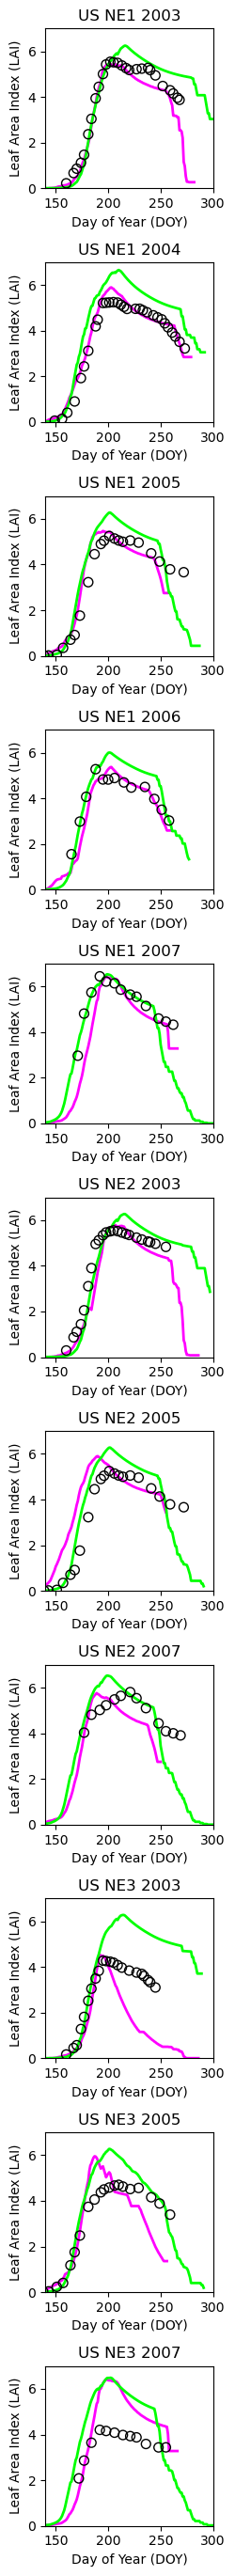

In [3]:
# ---------------------------------------------------------------------------
# LAI — Leaf Area Index  (all 11 site-years)
# ---------------------------------------------------------------------------
LAI_OBS = sorted(glob.glob(OBS_LAI_PATTERN))

plot_variable(
    obs_paths=LAI_OBS, dssat_lookup=DSSAT_LOOKUP, wofost_lookup=WOFOST_LOOKUP,
    obs_date_col='Date', obs_val_col='Real_LAI',
    dssat_col='LAID', wofost_col='LAI',
    ylabel='Leaf Area Index (LAI)', ylim_max=7,
    obs_marker_size=50, model_lw=2
)

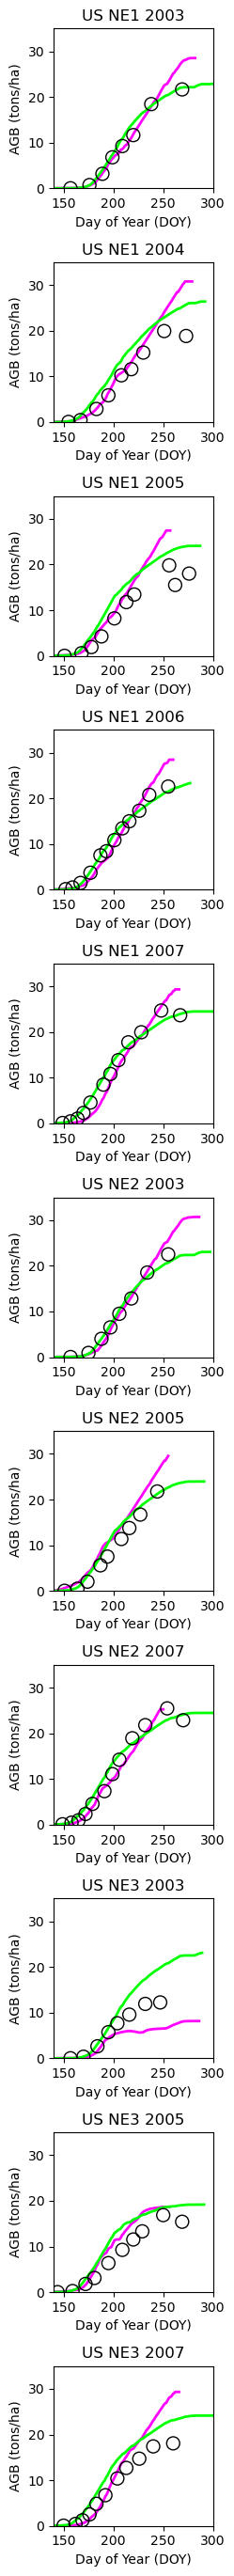

In [4]:
# ---------------------------------------------------------------------------
# AGB — Above-Ground Biomass  (all 11 site-years)
# ---------------------------------------------------------------------------
AGB_OBS = sorted(glob.glob(OBS_AGB_PATTERN))

plot_variable(
    obs_paths=AGB_OBS, dssat_lookup=DSSAT_LOOKUP, wofost_lookup=WOFOST_LOOKUP,
    obs_date_col='Date', obs_val_col='Real_AGB',
    dssat_col='AGB', wofost_col='TAGP',
    ylabel='AGB (tons/ha)', ylim_max=35,
    obs_marker_size=100,
    dssat_scale=0.001, wofost_scale=0.001,
    model_lw=2
)

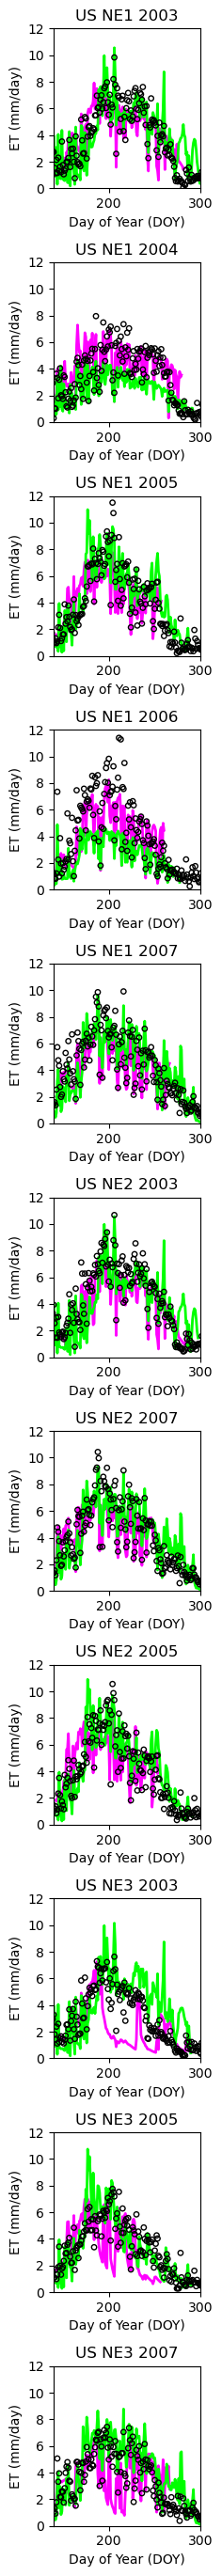

In [5]:
# ---------------------------------------------------------------------------
# ET — Evapotranspiration  (all 11 site-years)
# ---------------------------------------------------------------------------
ET_OBS = sorted(glob.glob(OBS_ET_PATTERN))

plot_variable(
    obs_paths=ET_OBS, dssat_lookup=DSSAT_LOOKUP, wofost_lookup=WOFOST_LOOKUP,
    obs_date_col='date', obs_val_col='ET_corr',
    dssat_col='ET', wofost_col=None,
    wofost_sum_cols=['TRA', 'EVS'], wofost_scale=10.0,
    ylabel='ET (mm/day)', ylim_max=12,
    obs_marker_size=15, model_lw=2
)

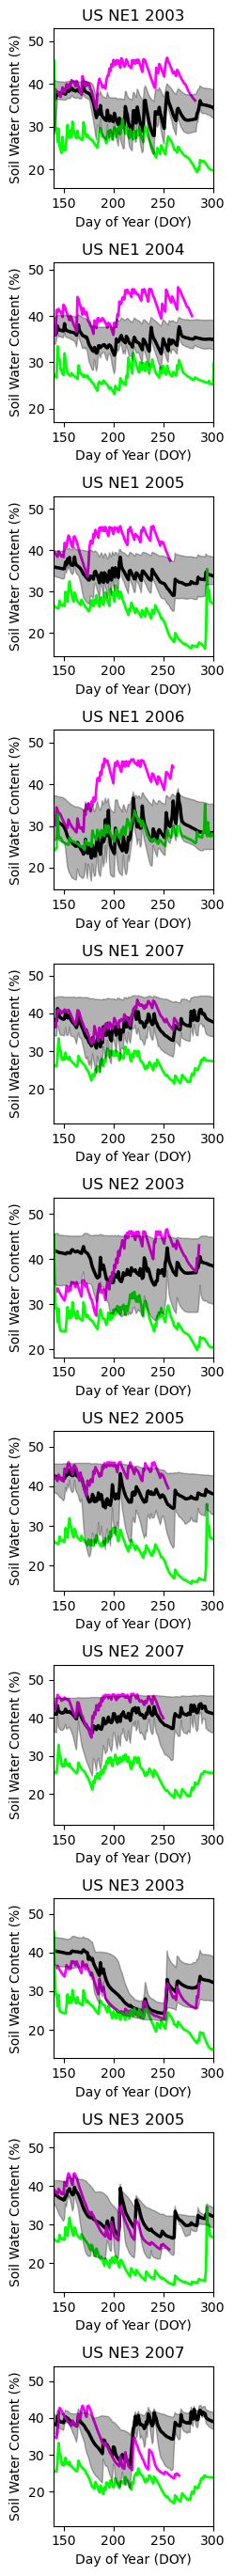

In [6]:
# ---------------------------------------------------------------------------
# SWC — Soil Water Content  (all 11 site-years)
# ---------------------------------------------------------------------------
SWC_OBS = sorted(glob.glob(OBS_SWC_PATTERN))

plot_variable(
    obs_paths=SWC_OBS, dssat_lookup=DSSAT_LOOKUP, wofost_lookup=WOFOST_LOOKUP,
    obs_date_col='DATE', obs_val_col='mean_SWC',
    dssat_col='SW_Mean', wofost_col='SM',
    ylabel='Soil Water Content (%)', ylim_max=None,
    dssat_scale=100, wofost_scale=100,
    obs_style='line', obs_fill_cols=('MIN_SWC', 'MAX_SWC'),
    model_lw=2
)

C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\2381587293.py:65: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[cfg['obs_date_col']] = pd.to_datetime(
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\2381587293.py:65: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[cfg['obs_date_col']] = pd.to_datetime(
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\2381587293.py:65: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  obs[cfg['obs_date_col']] = pd.to_datetime(
C:\Users\yaron\AppData\Local\Temp\ipykernel_31788\2381587293.py:65: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=

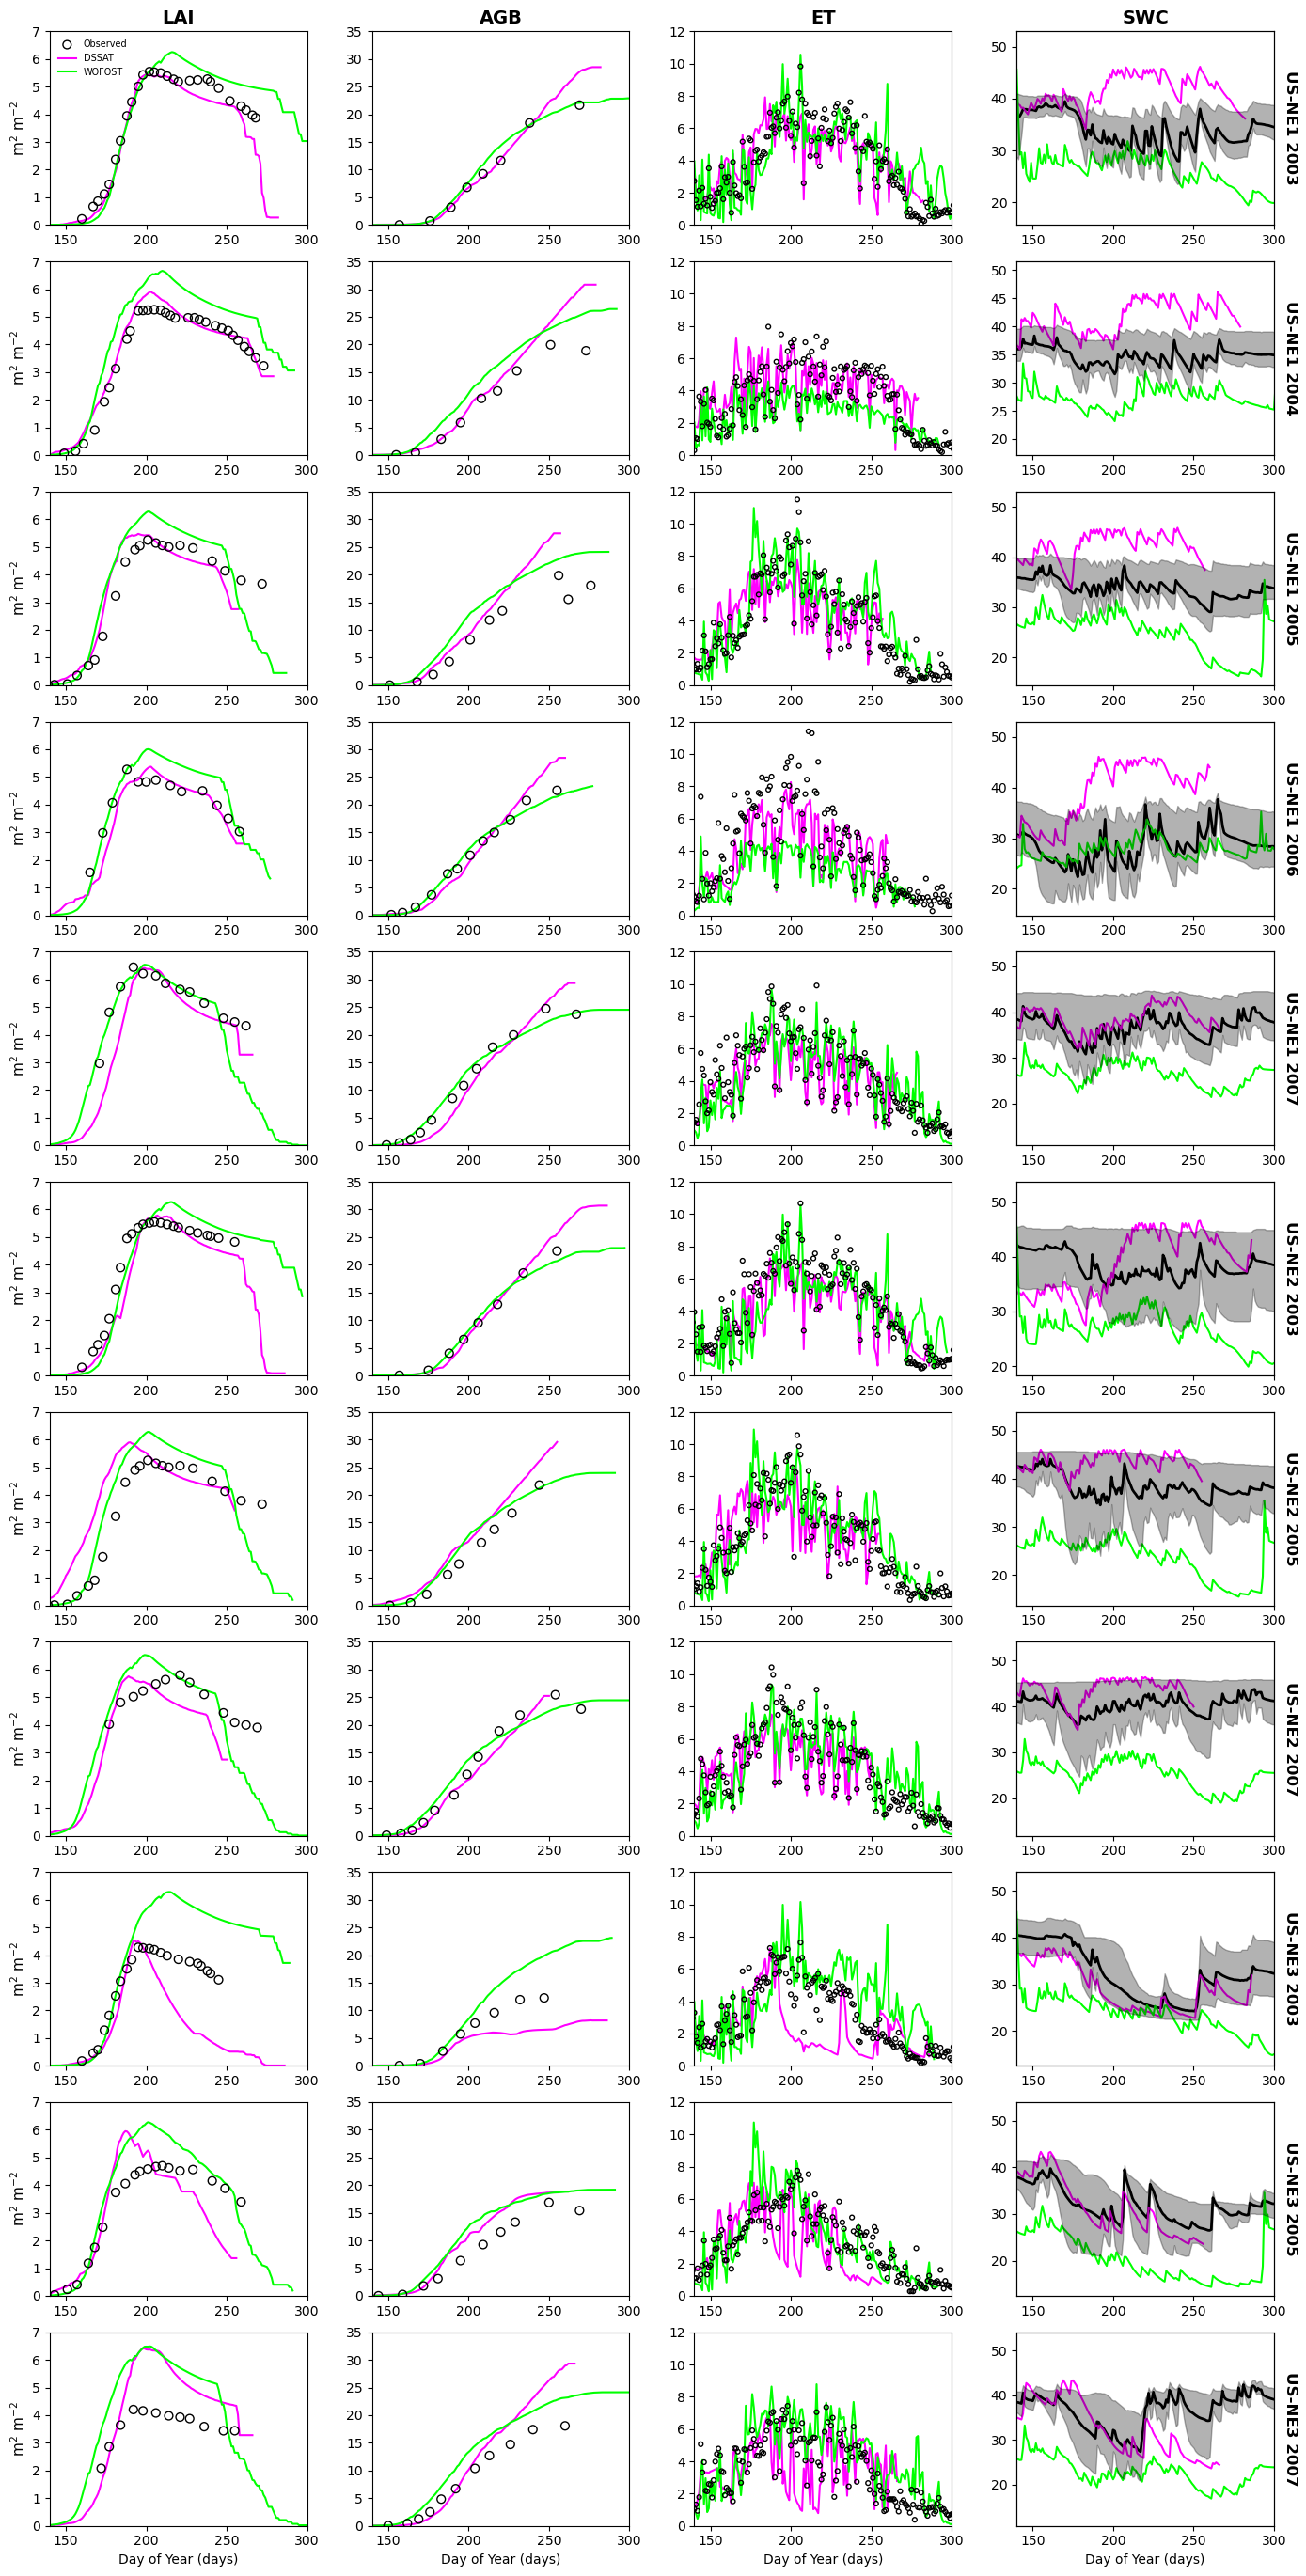

Saved Figures/fig_compare_model_maize_combined.png


In [7]:
# ---------------------------------------------------------------------------
# Combined 11×4 figure  (rows = site-years, cols = LAI / AGB / ET / SWC)
# Uses site-year key matching for correct obs↔model pairing
# ---------------------------------------------------------------------------
VARIABLES = [
    dict(obs_pattern=OBS_LAI_PATTERN, obs_date_col='Date', obs_val_col='Real_LAI',
         dssat_col='LAID', wofost_col='LAI',
         wofost_sum_cols=None, ylabel='m$^2$ m$^{-2}$', ylim_max=7,
         dssat_scale=1, wofost_scale=1,
         obs_style='scatter', obs_marker_size=40,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_AGB_PATTERN, obs_date_col='Date', obs_val_col='Real_AGB',
         dssat_col='AGB', wofost_col='TAGP',
         wofost_sum_cols=None, ylabel='tons ha$^{-1}$', ylim_max=35,
         dssat_scale=0.001, wofost_scale=0.001,
         obs_style='scatter', obs_marker_size=40,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_ET_PATTERN, obs_date_col='date', obs_val_col='ET_corr',
         dssat_col='ET', wofost_col=None,
         wofost_sum_cols=['TRA', 'EVS'], ylabel='mm d$^{-1}$', ylim_max=12,
         dssat_scale=1, wofost_scale=10.0,
         obs_style='scatter', obs_marker_size=12,
         obs_fill_cols=None, model_lw=1.5),
    dict(obs_pattern=OBS_SWC_PATTERN, obs_date_col='DATE', obs_val_col='mean_SWC',
         dssat_col='SW_Mean', wofost_col='SM',
         wofost_sum_cols=None, ylabel='%', ylim_max=None,
         dssat_scale=100, wofost_scale=100,
         obs_style='line', obs_marker_size=50,
         obs_fill_cols=('MIN_SWC', 'MAX_SWC'), model_lw=1.5),
]

COL_TITLES = ['LAI', 'AGB', 'ET', 'SWC']
NROWS = len(SITE_YEARS)
NCOLS = len(VARIABLES)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(14, 2.5 * NROWS))

for col_idx, cfg in enumerate(VARIABLES):
    OBS_PATHS = sorted(glob.glob(cfg['obs_pattern']))
    obs_lookup = build_lookup(OBS_PATHS)

    for row_idx, sy_key in enumerate(SITE_YEARS):
        ax = axes[row_idx, col_idx]

        # Skip if no obs file for this site-year
        if sy_key not in obs_lookup:
            ax.set_xlim(140, 300)
            if cfg['ylim_max'] is not None:
                ax.set_ylim(0, cfg['ylim_max'])
            ax.grid(False)
            if row_idx == 0:
                ax.set_title(COL_TITLES[col_idx], fontsize=14, fontweight='bold')
            if col_idx == 0:
                ax.set_ylabel(cfg['ylabel'], fontsize=11)
            if row_idx == NROWS - 1:
                ax.set_xlabel('Day of Year (days)', fontsize=10)
            continue

        obs_path = obs_lookup[sy_key]
        site_label = f'US-{sy_key[0]}'
        year = sy_key[1]

        # --- Observed ---
        obs = pd.read_csv(obs_path)
        obs[cfg['obs_date_col']] = pd.to_datetime(
            obs[cfg['obs_date_col']], errors='coerce')
        obs['DOY'] = obs[cfg['obs_date_col']].dt.dayofyear
        if cfg['obs_val_col'] == 'Real_LAI' and 'Real_LAI' not in obs.columns and 'LAI' in obs.columns:
            obs = obs.rename(columns={'LAI': 'Real_LAI'})

        # --- DSSAT (matched by site-year key) ---
        ds = pd.read_csv(DSSAT_LOOKUP[sy_key])
        ds['Date'] = pd.to_datetime(ds['Date'])
        ds['DOY'] = ds['Date'].dt.dayofyear
        if cfg['dssat_col'] == 'AGB' and 'AGB' not in ds.columns and 'CWAD' in ds.columns:
            ds.rename(columns={'CWAD': 'AGB'}, inplace=True)
        if cfg['dssat_col'] == 'ET' and 'ET' not in ds.columns and 'ETAA' in ds.columns:
            ds.rename(columns={'ETAA': 'ET'}, inplace=True)
        if cfg['dssat_col'] == 'SW_Mean' and 'SW_Mean' not in ds.columns:
            sw_cols = [c for c in ds.columns if re.match(r'SW\dD$', c)]
            if sw_cols:
                ds['SW_Mean'] = ds[sw_cols].mean(axis=1)

        # --- WOFOST (matched by site-year key) ---
        wo = pd.read_csv(WOFOST_LOOKUP[sy_key])
        wo['day'] = pd.to_datetime(wo['day'])
        wo['DOY'] = wo['day'].dt.dayofyear

        if cfg['wofost_sum_cols']:
            wo_val = sum(wo[c] for c in cfg['wofost_sum_cols']) * cfg['wofost_scale']
        else:
            wo_val = wo[cfg['wofost_col']] * cfg['wofost_scale']

        # --- Plot observed ---
        if cfg['obs_style'] == 'scatter':
            ax.scatter(obs['DOY'], obs[cfg['obs_val_col']],
                       edgecolor='black', facecolor='none', marker='o',
                       s=cfg['obs_marker_size'], label='Observed', zorder=3)
        else:
            ax.plot(obs['DOY'], obs[cfg['obs_val_col']], color='black',
                    label='Observed', linewidth=2)
            if cfg['obs_fill_cols']:
                ax.fill_between(obs['DOY'],
                                obs[cfg['obs_fill_cols'][0]],
                                obs[cfg['obs_fill_cols'][1]],
                                color='black', alpha=0.3, zorder=5)

        # --- Plot models ---
        ax.plot(ds['DOY'], ds[cfg['dssat_col']] * cfg['dssat_scale'],
                color=COLOR_DSSAT, label='DSSAT', linewidth=cfg['model_lw'])
        ax.plot(wo['DOY'], wo_val,
                color=COLOR_WOFOST, label='WOFOST', linewidth=cfg['model_lw'])

        ax.set_xlim(140, 300)
        if cfg['ylim_max'] is not None:
            ax.set_ylim(0, cfg['ylim_max'])
        ax.grid(False)

        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], fontsize=14, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(cfg['ylabel'], fontsize=11)
        else:
            ax.set_ylabel('')
        if row_idx == NROWS - 1:
            ax.set_xlabel('Day of Year (days)', fontsize=10)
        else:
            ax.set_xlabel('')

        if col_idx == NCOLS - 1:
            ax_right = ax.twinx()
            ax_right.set_yticks([])
            ax_right.set_ylabel(f'{site_label} {year}',
                                fontsize=12, fontweight='bold', rotation=270,
                                labelpad=18)

        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc='upper left',
                      framealpha=0.8, edgecolor='none')

plt.tight_layout()
plt.savefig('Figures/fig_compare_model_maize_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved Figures/fig_compare_model_maize_combined.png')